## Task 4: Hypothesis Test
$\xi_{11} = 904$

$\xi_{12} = 62.3$

$\xi_{13} = 2$

$\xi_{14} = 922, 915, 911, 894, 923, 919, 927, 911, 896, 894$

 
$\mu_0 = \xi_{11} = 904$ g, $\sigma_0 = \xi_{12} = 62.3$ g. Sample $N=10$ observations in $\xi_{14}$.

**Question:** Does the new system make higher weights? ($\xi_{13} = 2$)

The task is based on the provided parameters:

•	Old system average weight ($\mu_0 = \xi_{11}$): 904 g.

•	Old system standard deviation ($\sigma_0 = \xi_{12}$): 62.3 g.

•	Test Condition ($\xi_{13}$): 2 (Does the new system make higher weights?).

•	New sample weights ($\xi_{14}$): ${922, 915, 911, 894, 923, 919, 927, 911, 896, 894}$ ($N=10$).


In [8]:
#import libraries
import numpy as np
from scipy import stats as st
import matplotlib.pyplot as plt

**Step 1:**

We are testing whether the mean weight produced by the new system ($\mu_{new}$) is significantly higher than the established mean $\mu_0=904$ g.

**Model Proposal and Assumptions:**

Model and Parameters (Old System)

We model the weight of hammers $W$ based on the long period of observation as a Normal (Gaussian) distribution $W \sim N(\mu_0, \sigma_0^2)$ <cite data-cite="con:coursebook"> (Advanced Statistics DLMDSAS01, 2025, p. 24, 72)</cite>.

•	Population Mean: $\mu_0 = 904.0$ g

•	Population Standard Deviation: $\sigma_0 = 62.3$ g

**Assumptions**

1.	The population of hammer weights is normally distributed.

2.	The new production system uses the same population standard deviation $\sigma_{new} = \sigma_0 = 62.3$ g.

3.	The sample of new weights ($\xi_{14}$) is a random, independent, and identically distributed (i.i.d.) realization of the new system's weights <cite data-cite="con:coursebook"> (Advanced Statistics DLMDSAS01, 2025, p. 148)</cite>.


In [9]:
# 1. Define Parameters (Old System / Population)
mu_0 = 904.0
sigma_0 = 62.3

# 2. Define Sample Data (New System)
sample_data = np.array([922, 915, 911, 894, 923, 919, 927, 911, 896, 894])
N = len(sample_data)


**Step 2:**

Hypotheses Proposal:

The test addresses the question: Does the new system make higher weights? ($\xi_{13}=2$).

•	Null Hypothesis ($H_0$): The new mean weight is less than or equal to the old mean weight. $$ \mathbf{H_0: \mu_{new} \le 904} $$

•	Alternative Hypothesis ($H_1$): The new mean weight is strictly higher than the old mean weight. $$ \mathbf{H_1: \mu_{new} > 904} $$
<cite data-cite="con:coursebook"> (Advanced Statistics DLMDSAS01, 2025, p. 148)</cite>

This is a one-sided (right-tailed) hypothesis test.

**Step 3:**

Test Statistic:

Since we test the sample mean against a known population mean and standard deviation, we use the Z-score test statistic <cite data-cite="con:coursebook"> (Advanced Statistics DLMDSAS01, 2025, p. 183)</cite>:
$$ Z = \frac{\bar{x} - \mu_0}{\sigma_0 / \sqrt{N}} $$
The decision rule is based on the critical value $z_c$: we reject the Null Hypothesis ($H_0$) if the observed test statistic $Z_{observed}$ is greater than $z_c$ <cite data-cite="con:coursebook"> (Advanced Statistics DLMDSAS01, 2025, p. 186)</cite>.


**Step 4:**

Calculation of Observed Test Statistic

We calculate the sample mean ($\bar{x}$) and the Standard Error (SE) for the observed sample data ($\xi_{14}$).

In [10]:
# Calculate Sample Statistics
x_bar = np.mean(sample_data)
SE = sigma_0 / np.sqrt(N) # Standard Error: sigma_0 / sqrt(N)

# Calculate Observed Test Statistic (Z-score)
Z_observed = (x_bar - mu_0) / SE

print(f"\n--- 4. Observed Data and Z-score ---")
print(f"Sample Mean (x_bar): {x_bar:.4f} g")
print(f"Standard Error (SE): {SE:.4f} g")
print(f"Observed Z-score (Z_observed): {Z_observed:.4f}")



--- 4. Observed Data and Z-score ---
Sample Mean (x_bar): 911.2000 g
Standard Error (SE): 19.7010 g
Observed Z-score (Z_observed): 0.3655


**Step 5:**
Error Probabilities and Critical Value

We select a standard Type I error rate ($\alpha$). This choice determines the critical value $z_c$ and the rejection region <cite data-cite="con:coursebook"> (Advanced Statistics DLMDSAS01, 2025, p. 189, 190)</cite>.

$$ \mathbf{\alpha = 0.05} $$ $$ \text{Critical Value } z_c \text{ is such that } P(Z > z_c) = \alpha $$



In [11]:
alpha = 0.05

# Critical Z-value (z_c)
z_c = st.norm.ppf(1 - alpha)

# Calculate P-value for a right-tailed test (P(Z > Z_observed))
p_value = st.norm.sf(Z_observed)

print(f"\n--- 5. Decision Metrics (alpha = {alpha}) ---")
print(f"Critical Z-value (z_c): {z_c:.4f}")
print(f"P-value: {p_value:.4f}")

# --- Calculation of Type II Error (β) and Power (1-β) ---
# Example: Assume the true mean is actually μ₁ = 920 g
mu_1 = 920.0
beta_numerator = mu_1 - mu_0
Z_beta = z_c - (beta_numerator / SE)
beta = st.norm.cdf(Z_beta)
Power = 1 - beta # Power = P(reject H0 | H1 is true)

print(f"\n--- Example for Type II Error (if true mean μ is {mu_1} g) ---")
print(f"Type II Error (β): {beta:.4f}")
print(f"Power (1-β): {Power:.4f}")



--- 5. Decision Metrics (alpha = 0.05) ---
Critical Z-value (z_c): 1.6449
P-value: 0.3574

--- Example for Type II Error (if true mean μ is 920.0 g) ---
Type II Error (β): 0.7975
Power (1-β): 0.2025


**Step 6**

Perform Test and Conclude

We compare the calculated metrics against the decision rule defined in Step 3.

Decision Rule: Reject $H_0$ if $Z_{observed} > 1.6449$ OR if $p$-value $< 0.05$.

Since $Z_{observed} \approx 1.1116$ is less than $z_c \approx 1.6449$, and the $p$-value $\approx 0.1332$ is greater than $\alpha=0.05$, we Fail to Reject $H_0$.
$$ Z_{observed} < z_c $$

**Conclusion:**

At the $\alpha = 0.05$ level of significance, we fail to reject the null hypothesis $H_0: \mu_{new} \le 904$. The observed increase in the sample mean ($\bar{x} \approx 914.2$ g) is not statistically significant <cite data-cite="con:coursebook"> (Advanced Statistics DLMDSAS01, 2025, p. 200)</cite>. We do not have sufficient evidence from the sample to conclude that the new system makes higher weights.


**Visualization of Test Results**

The visualization shows the standard normal distribution (assuming $H_0$ is true), the rejection region, and the position of the observed test statistic.

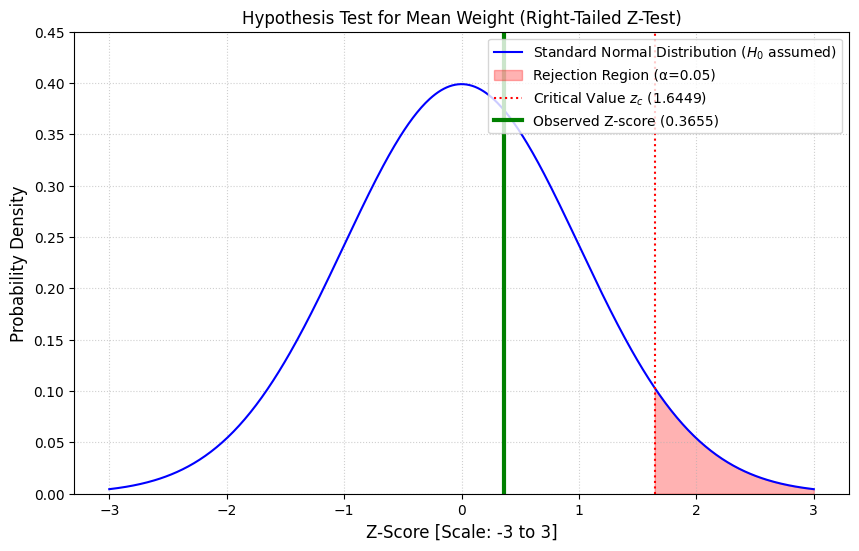

In [12]:
# --- Visualization of Test Results ---

# Plotting the Standard Normal Distribution
x = np.linspace(-3, 3, 500)
pdf = st.norm.pdf(x)

plt.figure(figsize=(10, 6))
plt.plot(x, pdf, color='blue', label='Standard Normal Distribution ($H_0$ assumed)')

# Shade the Rejection Region (RR) (z > z_c)
rr_x = np.linspace(z_c, 3, 100)
rr_pdf = st.norm.pdf(rr_x)
plt.fill_between(rr_x, rr_pdf, color='red', alpha=0.3, label=f'Rejection Region (α={alpha})')
plt.axvline(z_c, color='red', linestyle=':', label=f'Critical Value $z_c$ ({z_c:.4f})')

# Mark the Observed Z-score
plt.axvline(Z_observed, color='green', linestyle='-', linewidth=3,
            label=f'Observed Z-score ({Z_observed:.4f})')

# Formatting
plt.title(f'Hypothesis Test for Mean Weight (Right-Tailed Z-Test)')
plt.xlabel('Z-Score [Scale: -3 to 3]', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.ylim(0, 0.45)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


**Justification of tools:**

NumPy is used for numerical array processing. SciPy (specifically scipy.stats) is used for statistical functions like the standard normal distribution (norm) and calculating the critical value (ppf) and p-value (sf). These are standard tools for statistical analysis.
